# Stage 4a — Generalised LoRA Fine-Tuning
## Model: `google/gemma-2-9b-it` | Dataset: CB1 (6-Class Cyberbullying)
**Framework:** Generalised LoRA — Wf = W(I + UV) + AB  
**Seed:** 42 | **Split:** 75/25 stratified | **Primary metric:** Macro F1 | **Secondary:** MCC

---

## README — Before Step 1

### Gemma-2-9B is the primary target model for Stage 4

Gemma-2-9B holds the **overall Stage 2 champion** result: F1=0.9010 at r=32.  
If Stage 4 Gemma-2-9B beats 0.9010, the central research hypothesis is proven.

### Gemma-2-9B specific facts

| Property | Value |
|---|---|
| **HF token** | Required |
| **dtype** | `bfloat16` |
| **Train batch** | 4 (9B model, A100 40/80GB — safe with dual adapter) |
| **Eval batch** | 16 |
| **PEFT layers** | 168 |
| **Eff. rank** | 2815.98 — perfectly constant across all ranks in both S2 and S3 (strongest validation of Proposition 1) |

### Cross-stage reference

| Stage | r=4 | r=8 | r=16 | r=32 | Best | Eff.Rank |
|---|---|---|---|---|---|---|
| S2 (additive) | 0.8951 | 0.8954 | 0.8986 | **0.9010 ★** | r=32 | 2815.98 ✓ perfectly constant |
| S3 (multiplicative) | 0.8757 | 0.8925 | 0.8937 | 0.8944 | r=32 | 2815.95–2815.98 ✓ |
| S4 Llama-3B (ref) | 0.8896 | 0.8945 | **0.8981** | 0.8967 | r=16 | TBD |
| S4 Mistral-7B (ref) | 0.8777 | 0.8289 | **0.8975** | 0.7451 | r=16 | 2515–2523 ⚠ varies |

### Key pattern: Gemma-2-9B is the most stable model

- Eff. rank perfectly constant (range 0.03) — strongest Proposition 1 validation
- No rank collapses in any stage
- Monotonically increasing F1 with rank in both S2 and S3
- S2 best was at r=32 → expect S4 best also at high rank

### Bugs fixed (all carried from Mistral Stage 4 fix)

1. `transformers>=4.47.0,<4.52.0` — avoids float8_e8m0fnu
2. `torch_dtype=` not `dtype=` in from_pretrained()
3. `eval_strategy=` not `evaluation_strategy=`
4. Parameters initialised on `inner.weight.device` (CUDA) — not CPU
5. No `.to(dev)` in forward — `self.lora_*` accessed directly
6. `type(module).__name__` check in eff_rank — robust across restarts
7. `name.rsplit('.', 1)` parent navigation — fixes eff_rank Wf=0.00


---
## Step 1: Install Required Libraries

**After running: Runtime → Restart Runtime, then run from Step 2 onwards. Do NOT re-run Step 1.**


In [1]:
# ── Install with pinned versions — compatible with Colab torch 2.5.x ───────────
# transformers pinned <4.52 to avoid float8_e8m0fnu error with torch 2.5.x
!pip install -q \
    "transformers>=4.47.0,<4.52.0" \
    "peft>=0.14.0" \
    "bitsandbytes>=0.45.0" \
    "accelerate>=1.2.0" \
    "datasets>=3.0.0" \
    "numpy<2.1" \
    "pandas<3.0" \
    "torchvision==0.20.1" \
    "scikit-learn" \
    tqdm matplotlib seaborn

print("✓ Installation complete.")
print()
print("=" * 60)
print("  ACTION REQUIRED: Restart the Colab runtime now.")
print("  Runtime → Restart Runtime  (or Ctrl+M .)")
print("  After restart: run from Step 2 onwards.")
print("  Do NOT re-run Step 1 after restart.")
print("=" * 60)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 111.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

---
## Step 2: Import Libraries and Initial Setup

**Gemma-2-9B requires HF token** — add it via Colab Secrets (key icon in sidebar).


In [1]:
import os, random, collections, re
from typing import Dict, List
import numpy as np, pandas as pd, torch, torch.nn as nn
import matplotlib.pyplot as plt, seaborn as sns

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    balanced_accuracy_score, matthews_corrcoef,
)
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer,
    BitsAndBytesConfig, TrainingArguments, Trainer, TrainerCallback,
)
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model
import bitsandbytes.functional as bnb_F
import bitsandbytes as bnb
from google.colab import drive, userdata

def set_all_seeds(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✓ All random seeds fixed to {seed}.")

set_all_seeds(42)

def load_hf_token():
    token = userdata.get('HF_TOKEN')
    if token is None:
        raise ValueError("HF_TOKEN not found. Add via Colab Secrets.")
    os.environ['HF_TOKEN'] = token
    print("✓ HuggingFace token loaded.")
    return token

HF_TOKEN = load_hf_token()
drive.mount('/content/drive')
print("✓ Google Drive mounted.")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


✓ All random seeds fixed to 42.
✓ HuggingFace token loaded.
Mounted at /content/drive
✓ Google Drive mounted.
✓ Device: cuda
  GPU : NVIDIA A100-SXM4-40GB
  VRAM: 42.4 GB


---
## Step 3: Global Configuration

**Gemma-2-9B specific:** batch=4, HF token required, output dir updated.


In [2]:
MODEL_NAME   = "google/gemma-2-9b-it"
NUM_LABELS   = 6
MAX_LENGTH   = 256

LORA_RANK    = 16
LORA_ALPHA   = 16
LORA_DROPOUT = 0.05
TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'o_proj']
RANK_SWEEP   = [4, 8, 32]

NUM_EPOCHS       = 1
LEARNING_RATE    = 2e-4
TRAIN_BATCH_SIZE = 4      # 9B model — safe batch with dual adapter on A100
EVAL_BATCH_SIZE  = 16
WEIGHT_DECAY     = 0.01
EVAL_STEPS       = 200
LOGGING_STEPS    = 50
OUTPUT_DIR       = "/content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Gemma2_9B"

CB1_PATH             = "/content/drive/MyDrive/Datasets/cb1.csv"
TRAIN_RATIO          = 0.75
TEST_RATIO           = 0.25
VAL_FROM_TRAIN       = 0.10
SIMILARITY_THRESHOLD = 0.90
RANDOM_STATE         = 42

LABEL_MAPPING = {
    'not_cyberbullying': 0, 'gender': 1, 'religion': 2,
    'ethnicity': 3, 'age': 4, 'other_cyberbullying': 5,
}
ID2LABEL     = {v: k for k, v in LABEL_MAPPING.items()}
TARGET_NAMES = list(LABEL_MAPPING.keys())

print("✓ Configuration loaded.")
print(f"  Stage    : 4a — Generalised LoRA")
print(f"  Formula  : Wf = W(I + UV) + AB")
print(f"  Model    : {MODEL_NAME}")
print(f"  HF token : Required ✓")
print(f"  Batch    : train={TRAIN_BATCH_SIZE} | eval={EVAL_BATCH_SIZE}")
print(f"  LoRA rank: {LORA_RANK}  |  alpha: {LORA_ALPHA}  |  scaling: 1.0")
print(f"  Rank sweep: {RANK_SWEEP}")
print()
print("  ── Stage references (Gemma-2-9B CB1) ──")
print("  S2: r=4: 0.8951 | r=8: 0.8954 | r=16: 0.8986 | r=32: 0.9010★  ↑ monotonic")
print("  S3: r=4: 0.8757 | r=8: 0.8925 | r=16: 0.8937 | r=32: 0.8944   ↑ monotonic")
print("  Eff.Rank: 2815.98 — perfectly constant (strongest Prop 1 validation)")
print("  ★ TARGET: beat S2 r=32 F1=0.9010 — the overall CB1 champion")


✓ Configuration loaded.
  Stage    : 4a — Generalised LoRA
  Formula  : Wf = W(I + UV) + AB
  Model    : google/gemma-2-9b-it
  HF token : Required ✓
  Batch    : train=4 | eval=16
  LoRA rank: 16  |  alpha: 16  |  scaling: 1.0
  Rank sweep: [4, 8, 32]

  ── Stage references (Gemma-2-9B CB1) ──
  S2: r=4: 0.8951 | r=8: 0.8954 | r=16: 0.8986 | r=32: 0.9010★  ↑ monotonic
  S3: r=4: 0.8757 | r=8: 0.8925 | r=16: 0.8937 | r=32: 0.8944   ↑ monotonic
  Eff.Rank: 2815.98 — perfectly constant (strongest Prop 1 validation)
  ★ TARGET: beat S2 r=32 F1=0.9010 — the overall CB1 champion


---
## Step 4: Text Preprocessing

Identical to all prior stages — verbatim copy for reproducible split.

In [3]:
def preprocess_text_for_llm(text, remove_hashtags=False, remove_emojis=False):
    if not isinstance(text, str): return ""
    text = re.sub(r'\bRT\s+@\w+:\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'http\S+|www\.\S+', '[URL]', text)
    text = re.sub(r'@\w+', '[USER]', text)
    if remove_hashtags: text = re.sub(r'#(\w+)', r'\1', text)
    if remove_emojis: text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'([!?.])\1+', r'\1', text)
    if len(text.split()) < 3: return ""
    return text

print("Before:", "RT @user123: Check this out http://example.com !!! @someone is so dumb")
print("After: ", preprocess_text_for_llm("RT @user123: Check this out http://example.com !!! @someone is so dumb"))
print("\n✓ Preprocessing function defined.")


Before: RT @user123: Check this out http://example.com !!! @someone is so dumb
After:  Check this out [URL] ! [USER] is so dumb

✓ Preprocessing function defined.


---
## Step 5: Load and Clean the CB1 Dataset

Identical to all prior stages.

In [4]:
print("═" * 60)
print("CB1 DATASET LOADING & CLEANING")
print("═" * 60)
df = pd.read_csv(CB1_PATH)
print(f"\n[1] Raw dataset loaded: {len(df):,} samples")
df = df.rename(columns={'tweet_text': 'text', 'cyberbullying_type': 'label'})
corrupt_mask = df['text'].astype(str).str.strip().isin(['#NAME?','#REF!','#VALUE!','#N/A','nan',''])
df = df[~corrupt_mask].reset_index(drop=True)
print(f"[3] Removed {corrupt_mask.sum()} corrupt rows → {len(df):,} remaining")
df['text'] = df['text'].apply(preprocess_text_for_llm)
df = df[df['text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"[4] After preprocessing: {len(df):,} remaining")
text_label_counts = df.groupby('text')['label'].nunique()
conflicting = text_label_counts[text_label_counts > 1].index
df = df[~df['text'].isin(conflicting)].reset_index(drop=True)
print(f"[5] Removed annotation-conflict rows → {len(df):,} remaining")
before = len(df)
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
print(f"[6] Removed {before-len(df):,} exact duplicates → {len(df):,} remaining")
before = len(df)
df = df[df['text'].str.split().str.len() >= 3].reset_index(drop=True)
print(f"[7] Removed {before-len(df):,} short texts → {len(df):,} remaining")
assert len(set(df['label'].unique()) - set(LABEL_MAPPING.keys())) == 0

print("\n" + "═" * 60)
print("FINAL CB1 CLASS DISTRIBUTION")
print("═" * 60)
counts = df['label'].value_counts()
for label, count in counts.items():
    print(f"  {label:<25} {count:>6}  ({count/len(df)*100:.1f}%)")
print(f"  {'TOTAL':<25} {len(df):>6}")
print(f"\n  Imbalance ratio: {counts.max()/counts.min():.2f}×")


════════════════════════════════════════════════════════════
CB1 DATASET LOADING & CLEANING
════════════════════════════════════════════════════════════

[1] Raw dataset loaded: 47,692 samples
[3] Removed 0 corrupt rows → 47,692 remaining
[4] After preprocessing: 46,942 remaining
[5] Removed annotation-conflict rows → 43,692 remaining
[6] Removed 358 exact duplicates → 43,334 remaining
[7] Removed 0 short texts → 43,334 remaining

════════════════════════════════════════════════════════════
FINAL CB1 CLASS DISTRIBUTION
════════════════════════════════════════════════════════════
  religion                    7979  (18.4%)
  age                         7972  (18.4%)
  ethnicity                   7920  (18.3%)
  gender                      7509  (17.3%)
  not_cyberbullying           6130  (14.1%)
  other_cyberbullying         5824  (13.4%)
  TOTAL                      43334

  Imbalance ratio: 1.37×


---
## Step 6: Stratified 75/25 Split with Near-Duplicate Check

Identical — seed=42, same test set across all stages.

In [5]:
print("═" * 60)
print("DATASET SPLITTING — 75% train / 25% test")
print("═" * 60)
train_val_df, test_df = train_test_split(
    df, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=df['label'])
print(f"\n[1] Primary split → Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")

print(f"\n[2] Near-duplicate check (threshold: {SIMILARITY_THRESHOLD})...")
all_texts = list(train_val_df['text'].values) + list(test_df['text'].values)
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2, max_df=0.95)
tfidf_matrix = vectorizer.fit_transform(all_texts)
train_vecs = tfidf_matrix[:len(train_val_df)]
test_vecs = tfidf_matrix[len(train_val_df):]

leaked_indices = []
for start in range(0, len(test_df), 500):
    end = min(start+500, len(test_df))
    batch_sims = cosine_similarity(test_vecs[start:end], train_vecs)
    leaked_mask = batch_sims.max(axis=1) >= SIMILARITY_THRESHOLD
    leaked_indices.extend(test_df.index[start:end][leaked_mask].tolist())

print(f"    Found {len(leaked_indices)} near-duplicate test samples")
if leaked_indices:
    leaked = test_df.loc[leaked_indices]
    test_df = test_df.drop(leaked_indices).reset_index(drop=True)
    train_val_df = pd.concat([train_val_df, leaked], ignore_index=True)
    print(f"    Moved → Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")
else:
    train_val_df = train_val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

overlap = set(train_val_df['text'].tolist()) & set(test_df['text'].tolist())
assert len(overlap) == 0, f"DATA LEAKAGE: {len(overlap)} overlapping samples!"
print("    ✓ Data leakage assertion passed.")

train_df, val_df = train_test_split(
    train_val_df, test_size=VAL_FROM_TRAIN, random_state=RANDOM_STATE, stratify=train_val_df['label'])
train_df = train_df.reset_index(drop=True); val_df = val_df.reset_index(drop=True)
print(f"\n[3] Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(f"    ✓ Test = {len(test_df)/len(df)*100:.1f}% (target: 25.0%)")


════════════════════════════════════════════════════════════
DATASET SPLITTING — 75% train / 25% test
════════════════════════════════════════════════════════════

[1] Primary split → Train+Val: 32,500 | Test: 10,834

[2] Near-duplicate check (threshold: 0.9)...
    Found 504 near-duplicate test samples
    Moved → Train+Val: 33,004 | Test: 10,330
    ✓ Data leakage assertion passed.

[3] Train: 29,703 | Val: 3,301 | Test: 10,330
    ✓ Test = 23.8% (target: 25.0%)


---
## Step 7: Class Weights

Identical to all prior stages.

In [6]:
def get_class_weights(df, label_col='label'):
    counts = df[label_col].value_counts()
    total = len(df); n_classes = len(LABEL_MAPPING)
    weights = [total / (n_classes * counts.get(ID2LABEL[i], 1)) for i in range(n_classes)]
    weights_norm = [w / sum(weights) * n_classes for w in weights]
    print("Class weights:")
    for i, (cls, w) in enumerate(zip(TARGET_NAMES, weights_norm)):
        print(f"  [{i}] {cls:<25} {w:.4f}")
    return weights_norm

print("✓ get_class_weights() defined.")


✓ get_class_weights() defined.


---
## Step 8: Effective Rank — Generalised LoRA (all bugs fixed)

SVD on `Wf = W + W@(UV) + A@B`. Fixed: `type(module).__name__` check, better error diagnostics.  
Gemma-2-9B reference: 2815.98 (perfectly constant across all ranks and stages).


In [7]:
def calculate_effective_rank_generalised(model, threshold_ratio=1e-3):
    full_ranks, uv_ranks, ab_ranks, per_layer = [], [], [], []
    skipped = 0

    for name, module in model.named_modules():
        if type(module).__name__ != 'GeneralisedLoRALayer':
            continue
        try:
            U = module.lora_U.data.float(); V = module.lora_V.data.float()
            A = module.lora_A.data.float(); B = module.lora_B.data.float()
            UV = U @ V; AB = A @ B

            S_uv = torch.linalg.svdvals(UV)
            r_uv = int((S_uv > threshold_ratio * S_uv[0]).sum()) if S_uv[0] > 0 else 0
            uv_ranks.append(r_uv)

            S_ab = torch.linalg.svdvals(AB)
            r_ab = int((S_ab > threshold_ratio * S_ab[0]).sum()) if S_ab[0] > 0 else 0
            ab_ranks.append(r_ab)

            weight_obj = module.inner.weight
            try:
                if hasattr(weight_obj, 'quant_state'):
                    W = bnb_F.dequantize_4bit(weight_obj.data, weight_obj.quant_state).float()
                else:
                    W = weight_obj.data.float()
            except Exception as e:
                if skipped == 0: print(f"  ℹ First dequant error: {type(e).__name__}: {e}")
                skipped += 1; continue

            if W.shape[0] == module.m and W.shape[1] == module.n:
                pass
            elif W.shape[0] == module.n and W.shape[1] == module.m:
                W = W.T.contiguous()
            else:
                if skipped == 0: print(f"  ℹ Shape mismatch: W={list(W.shape)}, m={module.m}, n={module.n}")
                skipped += 1; continue

            Wf = W + W @ UV + AB
            S_Wf = torch.linalg.svdvals(Wf)
            r_Wf = int((S_Wf > threshold_ratio * S_Wf[0]).sum()) if S_Wf[0] > 0 else 0
            full_ranks.append(r_Wf)
            per_layer.append({'layer': name, 'rank_Wf': r_Wf, 'rank_UV': r_uv, 'rank_AB': r_ab})
        except Exception:
            skipped += 1; continue

    if skipped > 0: print(f"  ℹ {skipped} layers skipped")
    if not full_ranks: print("  ⚠ No GeneralisedLoRALayer found")

    return {
        "avg_eff_rank_Wf": float(np.mean(full_ranks)) if full_ranks else 0.0,
        "avg_eff_rank_UV": float(np.mean(uv_ranks)) if uv_ranks else 0.0,
        "avg_eff_rank_AB": float(np.mean(ab_ranks)) if ab_ranks else 0.0,
        "layer_count": len(full_ranks), "per_layer_ranks": per_layer,
    }

print("✓ calculate_effective_rank_generalised() defined.")
print("  Gemma-2-9B reference: 2815.98 (perfectly constant in S2 and S3)")


✓ calculate_effective_rank_generalised() defined.
  Gemma-2-9B reference: 2815.98 (perfectly constant in S2 and S3)


---
## Step 9: Evaluation Metrics

Identical to all prior stages.

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    accuracy = accuracy_score(labels, predictions)
    _, _, f1, _ = precision_recall_fscore_support(labels, predictions, average='macro', zero_division=0)
    mcc = matthews_corrcoef(labels, predictions)
    return {"accuracy": accuracy, "f1": f1, "mcc": mcc}

def evaluate_dataset(y_true, y_pred, dataset_name):
    print(f"\n{'═'*65}")
    print(f"FINAL EVALUATION — {dataset_name}")
    print(f"{'═'*65}")
    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    bal_accuracy = balanced_accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    print(f"  Accuracy          : {accuracy:.4f}")
    print(f"  Macro F1          : {macro_f1:.4f}  ← PRIMARY METRIC")
    print(f"  Weighted F1       : {weighted_f1:.4f}")
    print(f"  Balanced Accuracy : {bal_accuracy:.4f}")
    print(f"  MCC               : {mcc:.4f}  ← SECONDARY METRIC")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred, labels=list(range(NUM_LABELS)),
                                target_names=TARGET_NAMES, zero_division=0, digits=4))
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_LABELS)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES)
    axes[0].set_title(f'Confusion Matrix (Counts)\n{dataset_name}')
    axes[0].tick_params(axis='x', rotation=45)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, vmin=0, vmax=1)
    axes[1].set_title(f'Confusion Matrix (Normalised)\n{dataset_name}')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_{dataset_name.replace(' ','_')}.png", dpi=150, bbox_inches='tight')
    plt.show()
    return {'accuracy': accuracy, 'macro_f1': macro_f1, 'weighted_f1': weighted_f1,
            'balanced_accuracy': bal_accuracy, 'mcc': mcc}

def make_predictions(model, df_test, tokenizer, batch_size=32):
    model.eval(); all_preds = []
    texts = df_test['text'].tolist()
    for start in range(0, len(texts), batch_size):
        enc = tokenizer(texts[start:start+batch_size], padding='max_length',
                        truncation=True, max_length=MAX_LENGTH, return_tensors='pt').to(model.device)
        with torch.no_grad():
            logits = model(**enc).logits
        all_preds.extend(torch.argmax(logits, dim=-1).cpu().numpy().tolist())
    df_out = df_test.copy(); df_out['predictions'] = all_preds
    return df_out

print("✓ compute_metrics(), evaluate_dataset(), make_predictions() defined.")


✓ compute_metrics(), evaluate_dataset(), make_predictions() defined.


---
## Step 10: Stability System + Custom Trainer

Identical to Stages 2–4 Llama/Mistral. 2-panel stability plot.

In [9]:
class StabilityCallback(TrainerCallback):
    def __init__(self):
        self.train_losses = []; self.val_metrics = collections.defaultdict(list); self.val_steps = []
    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs or state.global_step == 0: return
        if 'loss' in logs: self.train_losses.append((state.global_step, float(logs['loss'])))
    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics: return
        self.val_steps.append(state.global_step)
        for k, v in metrics.items(): self.val_metrics[k.replace('eval_','')].append(float(v))
    def get_stability_report(self):
        report = {}
        if self.train_losses:
            arr = np.array([l for (_,l) in self.train_losses])
            report['loss_mean_overall'] = float(np.mean(arr))
            report['loss_std_overall'] = float(np.std(arr))
            report['loss_cv_overall'] = float(np.std(arr)/np.mean(arr)) if np.mean(arr) > 0 else 0.0
        for m, vals in self.val_metrics.items():
            if len(vals) > 1:
                a = np.array(vals)
                report[f'val_{m}_std'] = float(np.std(a)); report[f'val_{m}_range'] = float(a.max()-a.min())
                report[f'val_{m}_best'] = float(a.max()); report[f'val_{m}_final'] = float(a[-1])
        report['stability_score'] = round((report.get('loss_cv_overall',0)*0.5) + (report.get('val_f1_std',0)*0.5), 6)
        return report
    def plot_stability_curves(self, stage_label='Stage 4', save_path=None):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        if self.train_losses:
            steps = [s for (s,_) in self.train_losses]; losses = [l for (_,l) in self.train_losses]
            ax1.plot(steps, losses, color='steelblue', linewidth=0.7, alpha=0.5, label='Step loss')
            w = min(20, len(losses))
            if len(losses) >= w:
                roll = np.convolve(losses, np.ones(w)/w, mode='valid')
                ax1.plot(steps[w-1:], roll, color='navy', linewidth=2.2, label=f'Rolling mean (w={w})')
            ax1.set_title(f'{stage_label}\nTraining Loss'); ax1.set_xlabel('Step'); ax1.set_ylabel('Loss')
            ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
        if self.val_steps:
            ax2r = ax2.twinx() if 'mcc' in self.val_metrics else None
            if 'f1' in self.val_metrics:
                f1v = self.val_metrics['f1']
                ax2.plot(self.val_steps, f1v, 'o-', color='forestgreen', linewidth=2, markersize=5, label='Macro F1')
                mu, sd = float(np.mean(f1v)), float(np.std(f1v))
                ax2.axhline(mu, color='forestgreen', linestyle=':', alpha=0.6)
                ax2.fill_between(self.val_steps, [mu-sd]*len(self.val_steps), [mu+sd]*len(self.val_steps),
                                 color='forestgreen', alpha=0.10, label=f'±1 std (={sd:.4f})')
                ax2.set_ylabel('Macro F1', color='forestgreen'); ax2.tick_params(axis='y', labelcolor='forestgreen')
            if ax2r and 'mcc' in self.val_metrics:
                ax2r.plot(self.val_steps, self.val_metrics['mcc'], 's--', color='darkorange',
                          linewidth=1.5, markersize=4, label='MCC', alpha=0.8)
                ax2r.set_ylabel('MCC', color='darkorange'); ax2r.tick_params(axis='y', labelcolor='darkorange')
            l1, lb1 = ax2.get_legend_handles_labels()
            l2, lb2 = (ax2r.get_legend_handles_labels() if ax2r else ([], []))
            ax2.legend(l1+l2, lb1+lb2, fontsize=9)
            ax2.set_title(f'{stage_label}\nValidation Metrics'); ax2.set_xlabel('Step'); ax2.grid(True, alpha=0.3)
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight'); print(f"✓ Saved → {save_path}")
        plt.show()

class CustomTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = torch.tensor(class_weights, dtype=torch.float32) if class_weights is not None else None
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels"); outputs = model(**inputs); logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device)) if self.class_weights is not None else nn.CrossEntropyLoss()
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

print("✓ StabilityCallback, CustomTrainer defined.")


✓ StabilityCallback, CustomTrainer defined.


---
## Step 11: Generalised LoRA Adapter + Training Function

All bugs fixed. Parameters initialised on `inner.weight.device`. No `.to(dev)` in forward.

**Gemma-2-9B specific:** HF token passed to from_pretrained().


In [10]:
class GeneralisedLoRALayer(nn.Module):
    """
    Dual adapter: Wf = W(I + UV) + AB
    Forward: y = W·x + scaling·W·(U·(V·x)) + scaling·A·(B·x)
    Init: V=0, B=0 → Wf=W at start. Scaling = alpha/rank = 1.0.
    Params on inner.weight.device from init — no .to() in forward.
    """
    def __init__(self, base_layer, rank, dropout=0.05, alpha=None):
        super().__init__()
        self.rank = rank
        self.alpha = alpha if alpha is not None else rank
        self.scaling = self.alpha / self.rank

        inner = base_layer.base_layer if hasattr(base_layer, 'base_layer') else base_layer
        if hasattr(inner, 'in_features'):
            n, m = inner.in_features, inner.out_features
        elif hasattr(inner, 'weight'):
            n, m = inner.weight.shape[1], inner.weight.shape[0]
        else:
            raise ValueError(f"Cannot determine dims from {type(inner)}")

        self.n = n; self.m = m; self.inner = inner
        _dev = self.inner.weight.device

        self.lora_U = nn.Parameter(torch.empty(n, rank, device=_dev))
        self.lora_V = nn.Parameter(torch.zeros(rank, n, device=_dev))
        self.lora_A = nn.Parameter(torch.empty(m, rank, device=_dev))
        self.lora_B = nn.Parameter(torch.zeros(rank, n, device=_dev))

        nn.init.normal_(self.lora_U, mean=0.0, std=0.01)
        nn.init.normal_(self.lora_A, mean=0.0, std=0.01)

        self.dropout = nn.Dropout(p=dropout) if dropout > 0.0 else nn.Identity()
        for param in self.inner.parameters(): param.requires_grad = False

    def forward(self, x):
        base_out = self.inner(x)
        x_drop = self.dropout(x)

        lora_vx  = x_drop @ self.lora_V.T
        lora_uvx = lora_vx @ self.lora_U.T
        mult_out = self.inner(lora_uvx)

        lora_bx = x_drop @ self.lora_B.T
        add_out = lora_bx @ self.lora_A.T

        return base_out + self.scaling * mult_out + self.scaling * add_out


def apply_generalised_lora_over_peft(model, target_modules, rank, dropout=0.05, alpha=None):
    from peft.tuners.lora import LoraLayer
    if alpha is None: alpha = rank
    replaced = 0
    module_dict = dict(model.named_modules())

    for name, module in list(model.named_modules()):
        if not isinstance(module, LoraLayer): continue
        if not any(name.endswith(f'.{t}') or name == t for t in target_modules): continue
        parts = name.rsplit('.', 1)
        if len(parts) == 2:
            parent = module_dict.get(parts[0])
            if parent is None: continue
            attr_name = parts[1]
        else:
            parent = model; attr_name = name
        gen_layer = GeneralisedLoRALayer(module, rank=rank, dropout=dropout, alpha=alpha)
        setattr(parent, attr_name, gen_layer)
        replaced += 1

    print(f"  ✓ Replaced {replaced} PEFT LoraLayers with GeneralisedLoRALayer")
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return model, trainable, total


def run_generalised_lora(train_df, val_df, test_df, lora_rank, run_label=''):
    set_all_seeds(RANDOM_STATE)
    lora_alpha = lora_rank
    label = run_label or f'GeneralisedLoRA_r{lora_rank}'

    print(f'\n{"="*65}')
    print(f'  STAGE 4 — GENERALISED LoRA  |  {label}')
    print(f'  Model: {MODEL_NAME}  |  Rank: {lora_rank}  |  Scaling: 1.0')
    print(f'  Formula: Wf = W(I + UV) + AB   [both paths active]')
    print(f'{"="*65}')

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    run_dir = os.path.join(OUTPUT_DIR, label)
    os.makedirs(run_dir, exist_ok=True)

    print('\n[1] Loading tokenizer...')
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.pad_token_id = tokenizer.eos_token_id
    print(f'   Vocab: {tokenizer.vocab_size:,}')

    def tokenise(examples):
        return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=MAX_LENGTH)

    print('[2] Preparing datasets...')
    train_m = train_df.copy(); val_m = val_df.copy(); test_m = test_df.copy()
    for s in [train_m, val_m, test_m]:
        s['label'] = s['label'].map(LABEL_MAPPING)
        assert s['label'].notnull().all()
    hf_train = Dataset.from_pandas(train_m[['text','label']].reset_index(drop=True)).map(tokenise, batched=True, remove_columns=['text'])
    hf_val = Dataset.from_pandas(val_m[['text','label']].reset_index(drop=True)).map(tokenise, batched=True, remove_columns=['text'])
    hf_train.set_format('torch'); hf_val.set_format('torch')
    print(f'   Train: {len(hf_train):,} | Val: {len(hf_val):,} | Test: {len(test_m):,}')

    quant_config = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type='nf4',
        bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=torch.bfloat16)

    lora_config = LoraConfig(
        r=lora_rank, lora_alpha=lora_alpha, target_modules=TARGET_MODULES,
        lora_dropout=LORA_DROPOUT, bias='none', task_type='SEQ_CLS')

    print('[3] Loading model (4-bit NF4 QLoRA)...')
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, quantization_config=quant_config, num_labels=NUM_LABELS,
        torch_dtype=torch.bfloat16, device_map='auto', token=HF_TOKEN)
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.use_cache = False
    model = prepare_model_for_kbit_training(model)
    model = get_peft_model(model, lora_config)
    print('   PEFT shell registered.')

    print('[4] Injecting GeneralisedLoRALayer...')
    model, trainable, total = apply_generalised_lora_over_peft(
        model, TARGET_MODULES, rank=lora_rank, dropout=LORA_DROPOUT, alpha=lora_alpha)
    print(f'   Trainable: {trainable:,} | Total: {total:,} | {100*trainable/total:.4f}%')

    class_weights = get_class_weights(train_df)

    training_args = TrainingArguments(
        output_dir=run_dir, num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
        eval_strategy='steps', eval_steps=EVAL_STEPS,
        logging_steps=LOGGING_STEPS, save_strategy='no',
        load_best_model_at_end=False,
        fp16=False, bf16=True,
        report_to='none', remove_unused_columns=False,
    )

    stability_cb = StabilityCallback()
    trainer = CustomTrainer(
        model=model, args=training_args,
        train_dataset=hf_train, eval_dataset=hf_val,
        compute_metrics=compute_metrics, callbacks=[stability_cb],
        class_weights=class_weights)

    print(f'\n[5] Training (Wf = W(I+UV) + AB, r={lora_rank})...')
    train_result = trainer.train()
    train_runtime_s = train_result.metrics.get('train_runtime', 0)
    print(f'   Time: {train_runtime_s:.0f}s ({train_runtime_s/3600:.2f} hrs)')

    stab_report = stability_cb.get_stability_report()
    stab_score = stab_report.get('stability_score', float('nan'))
    print(f'   Stability: {stab_score:.4f}', end='  ')
    if stab_score < 0.05: print('✅ Very stable')
    elif stab_score < 0.15: print('🟡 Acceptable')
    else: print('🔴 Unstable')

    stability_cb.plot_stability_curves(
        stage_label=f'Stage 4 Gemma-2-9B — Generalised LoRA (r={lora_rank})',
        save_path=os.path.join(run_dir, f'stability_{label}.png'))

    print('\n[6] Computing effective rank...')
    rank_info = calculate_effective_rank_generalised(model)
    print(f'   Eff.Rank Wf: {rank_info["avg_eff_rank_Wf"]:.2f}  ← S2: 2815.98 | S3: 2815.98')
    print(f'   Eff.Rank UV: {rank_info["avg_eff_rank_UV"]:.2f} | AB: {rank_info["avg_eff_rank_AB"]:.2f}')
    print(f'   Layers: {rank_info["layer_count"]}')

    print('\n[7] Evaluating on test set...')
    test_preds = make_predictions(model, test_m, tokenizer)
    eval_results = evaluate_dataset(
        test_m['label'].tolist(), test_preds['predictions'].tolist(), f'Stage4_CB1_{label}')

    row = {
        'model': 'Gemma-2-9B', 'stage': '4a', 'formula': 'Wf=W(I+UV)+AB',
        'dataset': 'CB1', 'rank': lora_rank, 'trainable_params': trainable,
        'macro_f1': eval_results['macro_f1'], 'mcc': eval_results['mcc'],
        'accuracy': eval_results['accuracy'], 'balanced_accuracy': eval_results['balanced_accuracy'],
        'avg_eff_rank_Wf': rank_info['avg_eff_rank_Wf'],
        'avg_eff_rank_UV': rank_info['avg_eff_rank_UV'],
        'avg_eff_rank_AB': rank_info['avg_eff_rank_AB'],
        'stability_score': stab_score, 'train_runtime_s': train_runtime_s,
    }
    pd.DataFrame([row]).to_csv(os.path.join(run_dir, f'{label}_results.csv'), index=False)
    print(f'\n✓ Results saved → {run_dir}')

    del model, trainer; torch.cuda.empty_cache()

    return {**eval_results, 'lora_rank': lora_rank, 'trainable_params': trainable,
            'avg_eff_rank_Wf': rank_info['avg_eff_rank_Wf'],
            'avg_eff_rank_UV': rank_info['avg_eff_rank_UV'],
            'avg_eff_rank_AB': rank_info['avg_eff_rank_AB'],
            'stability_score': stab_score, 'stability_report': stab_report,
            'stability_cb': stability_cb, 'train_runtime_s': train_runtime_s}


print("✓ GeneralisedLoRALayer defined.  (device-aware init, no .to() in forward)")
print("✓ apply_generalised_lora_over_peft() defined.  (rsplit fix)")
print("✓ run_generalised_lora() defined.")


✓ GeneralisedLoRALayer defined.  (device-aware init, no .to() in forward)
✓ apply_generalised_lora_over_peft() defined.  (rsplit fix)
✓ run_generalised_lora() defined.


---
## Step 12: Execute — Default Run (r = 16)

**Expected time:** ~2.5–3.0 hrs on A100  
**References:**
- Stage 2 Gemma-2-9B r=16: F1=0.8986
- Stage 3 Gemma-2-9B r=16: F1=0.8937
- ★ Overall target: Stage 2 r=32: **F1=0.9010**


✓ All random seeds fixed to 42.

  STAGE 4 — GENERALISED LoRA  |  GeneralisedLoRA_r16
  Model: google/gemma-2-9b-it  |  Rank: 16  |  Scaling: 1.0
  Formula: Wf = W(I + UV) + AB   [both paths active]

[1] Loading tokenizer...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

   PEFT shell registered.
[4] Injecting GeneralisedLoRALayer...
  ✓ Replaced 168 PEFT LoraLayers with GeneralisedLoRALayer
   Trainable: 37,868,544 | Total: 5,117,797,888 | 0.7399%
Class weights:
  [0] not_cyberbullying         1.1500
  [1] gender                    0.9458
  [2] religion                  0.9007
  [3] ethnicity                 0.8859
  [4] age                       0.8985
  [5] other_cyberbullying       1.2190

[5] Training (Wf = W(I+UV) + AB, r=16)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.629200,1.168868,0.810360,0.772808,0.778949
400,0.681900,0.555907,0.850954,0.834606,0.821419
600,0.669900,0.812505,0.843381,0.808302,0.816205
800,0.803300,0.715281,0.808543,0.783665,0.786835
1000,0.422700,0.642679,0.870948,0.852093,0.847820
1200,0.829000,0.466807,0.869434,0.853663,0.845308
1400,0.792600,0.720629,0.833384,0.798787,0.809783
1600,0.860400,0.502214,0.885489,0.870997,0.864571
1800,0.506500,0.567493,0.870948,0.856907,0.846252
2000,0.531900,0.678572,0.864889,0.843723,0.844068


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

   Time: 12554s (3.49 hrs)
   Stability: 0.2169  🔴 Unstable
✓ Saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Gemma2_9B/GeneralisedLoRA_r16/stability_GeneralisedLoRA_r16.png


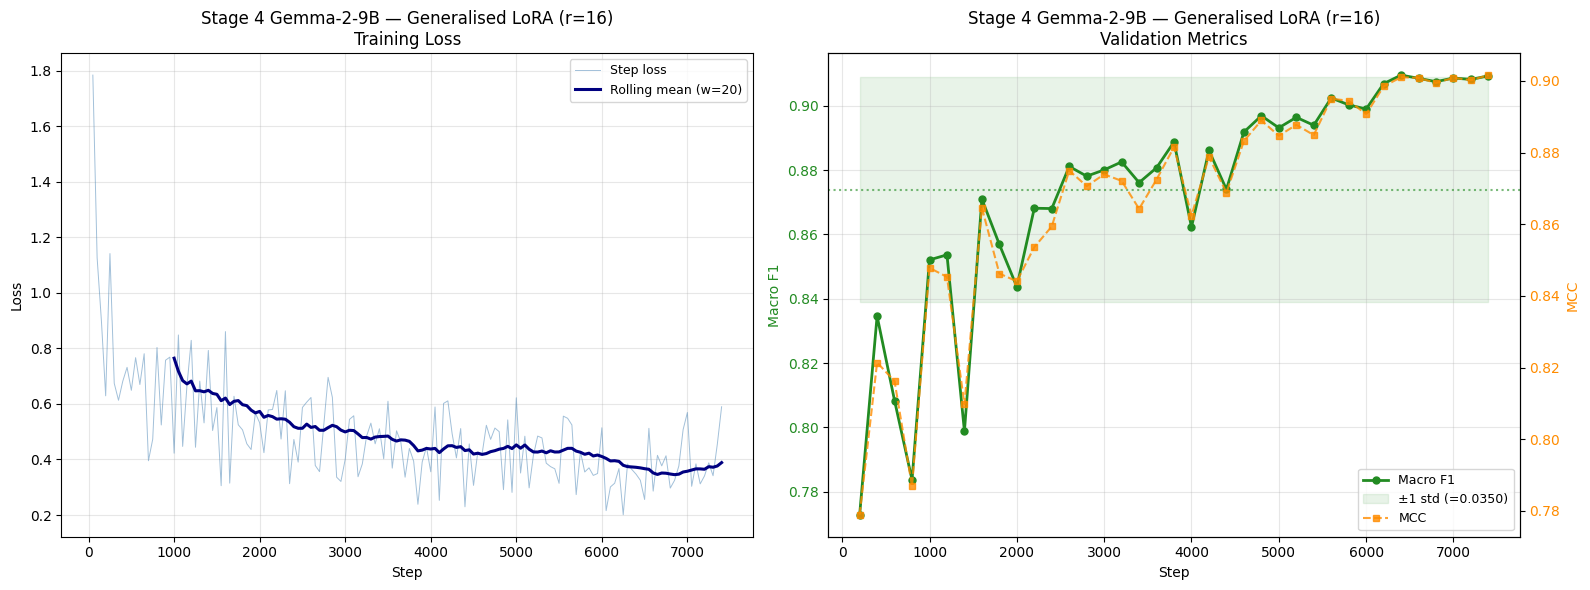


[6] Computing effective rank...


/tmp/ipykernel_1477/1986088909.py:13: UserWarning: torch.linalg.svd: During SVD computation with the selected cusolver driver, batches 0 failed to converge. A more accurate method will be used to compute the SVD as a fallback. Check doc at https://pytorch.org/docs/stable/generated/torch.linalg.svd.html (Triggered internally at ../aten/src/ATen/native/cuda/linalg/BatchLinearAlgebraLib.cpp:697.)
  S_uv = torch.linalg.svdvals(UV)


   Eff.Rank Wf: 2815.97  ← S2: 2815.98 | S3: 2815.98
   Eff.Rank UV: 16.00 | AB: 16.00
   Layers: 168

[7] Evaluating on test set...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — Stage4_CB1_GeneralisedLoRA_r16
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9129
  Macro F1          : 0.9014  ← PRIMARY METRIC
  Weighted F1       : 0.9125
  Balanced Accuracy : 0.9019
  MCC               : 0.8952  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7924    0.7212    0.7551      1424
             gender     0.9038    0.9144    0.9091      1788
           religion     0.9598    0.9696    0.9647      1971
          ethnicity     0.9852    0.9890    0.9871      1812
                age     0.9870    0.9703    0.9785      1950
other_cyberbullying     0.7830    0.8469    0.8137      1385

           accuracy                         0.

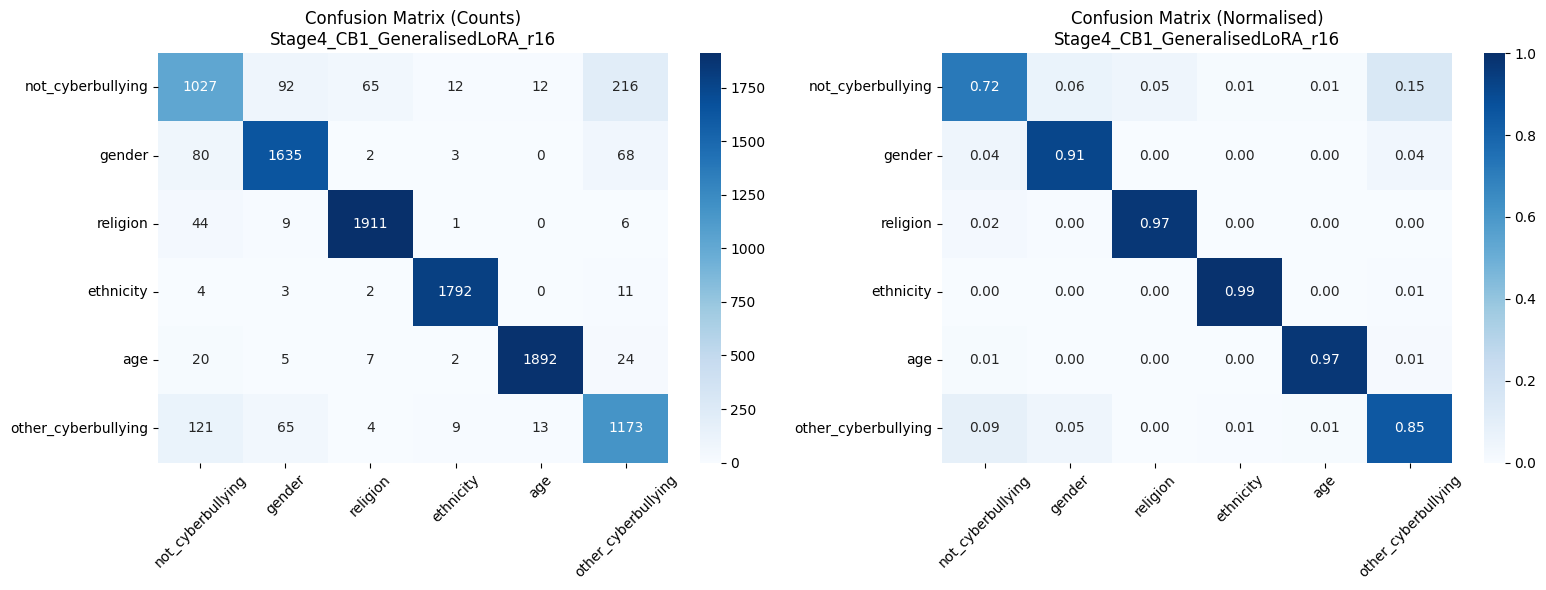


✓ Results saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Gemma2_9B/GeneralisedLoRA_r16

═════════════════════════════════════════════════════════════════
  STAGE 4 RESULTS — Gemma-2-9B r=16
═════════════════════════════════════════════════════════════════
  Macro F1          : 0.9014   ← PRIMARY
  MCC               : 0.8952
  Eff. rank (Wf)    : 2815.97  ← S2: 2815.98
  Stability         : 0.2169
  Time              : 3.49 hrs
  Δ vs S2 r=16      : +0.0028
  Δ vs S3 r=16      : +0.0077
  ★ BEATS OVERALL S2 CHAMPION (0.9010) AT r=16!

  → Step 13 sweeps r ∈ {{4, 8, 32}}.


In [11]:
results_r16 = run_generalised_lora(
    train_df=train_df, val_df=val_df, test_df=test_df,
    lora_rank=16, run_label='GeneralisedLoRA_r16')

print('\n' + '═'*65)
print('  STAGE 4 RESULTS — Gemma-2-9B r=16')
print('═'*65)
print(f'  Macro F1          : {results_r16["macro_f1"]:.4f}   ← PRIMARY')
print(f'  MCC               : {results_r16["mcc"]:.4f}')
print(f'  Eff. rank (Wf)    : {results_r16["avg_eff_rank_Wf"]:.2f}  ← S2: 2815.98')
print(f'  Stability         : {results_r16["stability_score"]:.4f}')
print(f'  Time              : {results_r16["train_runtime_s"]/3600:.2f} hrs')
print(f'  Δ vs S2 r=16      : {results_r16["macro_f1"] - 0.8986:+.4f}')
print(f'  Δ vs S3 r=16      : {results_r16["macro_f1"] - 0.8937:+.4f}')
if results_r16["macro_f1"] > 0.9010:
    print(f'  ★ BEATS OVERALL S2 CHAMPION (0.9010) AT r=16!')
print('\n  → Step 13 sweeps r ∈ {{4, 8, 32}}.')


---
## Step 13: Rank Sweep — r ∈ {4, 8, 32}

r=16 merged from Step 12. Gemma-2-9B's best was at r=32 in both S2 and S3 —  
expect the same pattern here. **r=32 is the most likely rank to beat 0.9010.**



───────────────────────────────────────────────────────
  Rank sweep: r=4
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 4 — GENERALISED LoRA  |  GeneralisedLoRA_r4
  Model: google/gemma-2-9b-it  |  Rank: 4  |  Scaling: 1.0
  Formula: Wf = W(I + UV) + AB   [both paths active]

[1] Loading tokenizer...
   Vocab: 256,000
[2] Preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

...

   PEFT shell registered.
[4] Injecting GeneralisedLoRALayer...
  ✓ Replaced 168 PEFT LoraLayers with GeneralisedLoRALayer
   Trainable: 9,483,264 | Total: 5,089,412,608 | 0.1863%
Class weights:
  [0] not_cyberbullying         1.1500
  [1] gender                    0.9458
  [2] religion                  0.9007
  [3] ethnicity                 0.8859
  [4] age                       0.8985
  [5] other_cyberbullying       1.2190

[5] Training (Wf = W(I+UV) + AB, r=4)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.449400,0.956574,0.811875,0.780714,0.777736
400,0.612400,0.511278,0.862466,0.846337,0.837342
600,0.492900,0.823288,0.841260,0.796226,0.815553
800,0.730600,0.529590,0.860042,0.848394,0.835959
1000,0.534700,0.660629,0.861860,0.842415,0.837462
1200,0.668000,0.562959,0.865798,0.844799,0.844430
1400,0.625200,0.474560,0.879128,0.865317,0.855972
1600,0.746700,0.504862,0.892457,0.877113,0.871706
1800,0.512700,0.682354,0.870948,0.853158,0.846274
2000,0.468100,0.514641,0.890639,0.878286,0.870774


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

   Time: 12903s (3.58 hrs)
   Stability: 0.2302  🔴 Unstable
✓ Saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Gemma2_9B/GeneralisedLoRA_r4/stability_GeneralisedLoRA_r4.png


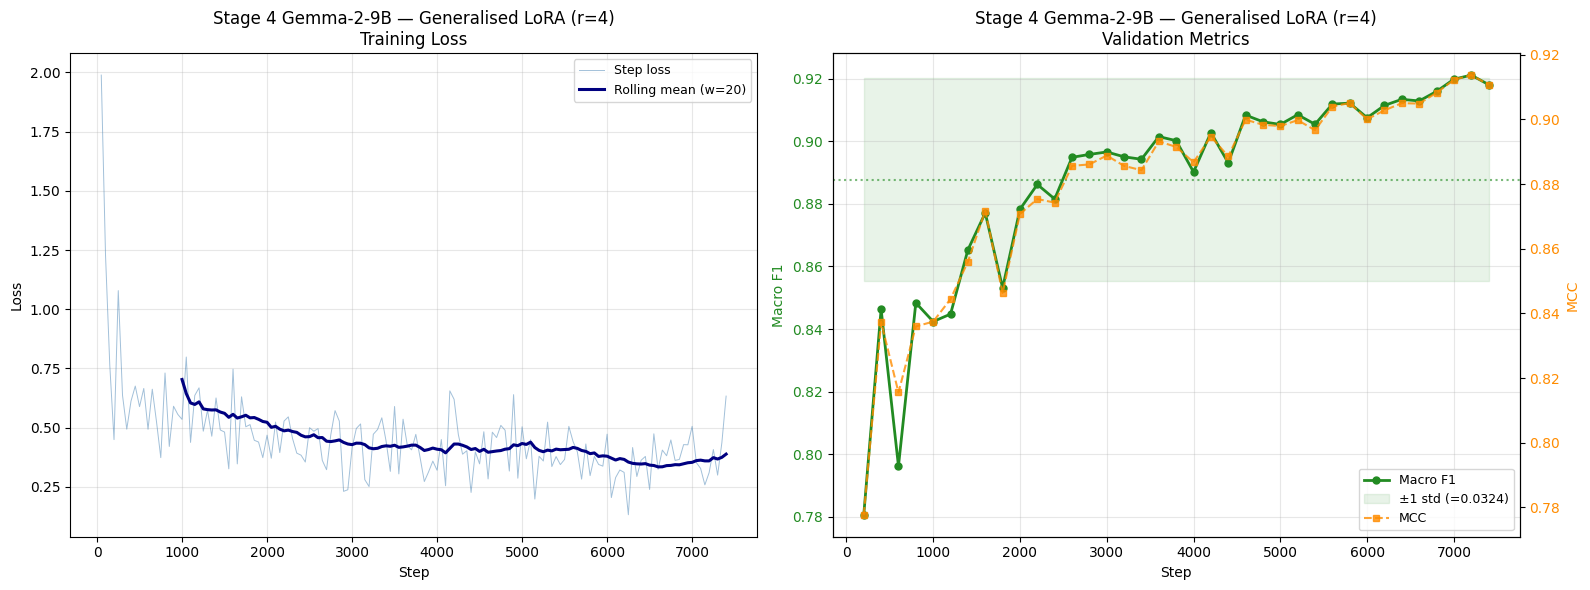


[6] Computing effective rank...
   Eff.Rank Wf: 2815.98  ← S2: 2815.98 | S3: 2815.98
   Eff.Rank UV: 4.00 | AB: 4.00
   Layers: 168

[7] Evaluating on test set...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — Stage4_CB1_GeneralisedLoRA_r4
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9185
  Macro F1          : 0.9082  ← PRIMARY METRIC
  Weighted F1       : 0.9183
  Balanced Accuracy : 0.9087
  MCC               : 0.9019  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7961    0.7514    0.7731      1424
             gender     0.9148    0.9183    0.9166      1788
           religion     0.9618    0.9706    0.9662      1971
          ethnicity     0.9835    0.9868    0.9851      1812
                age     0.9864    0.9692    0.9778      1950
other_cyberbullying     0.8072    0.8556    0.8307      1385

           accur

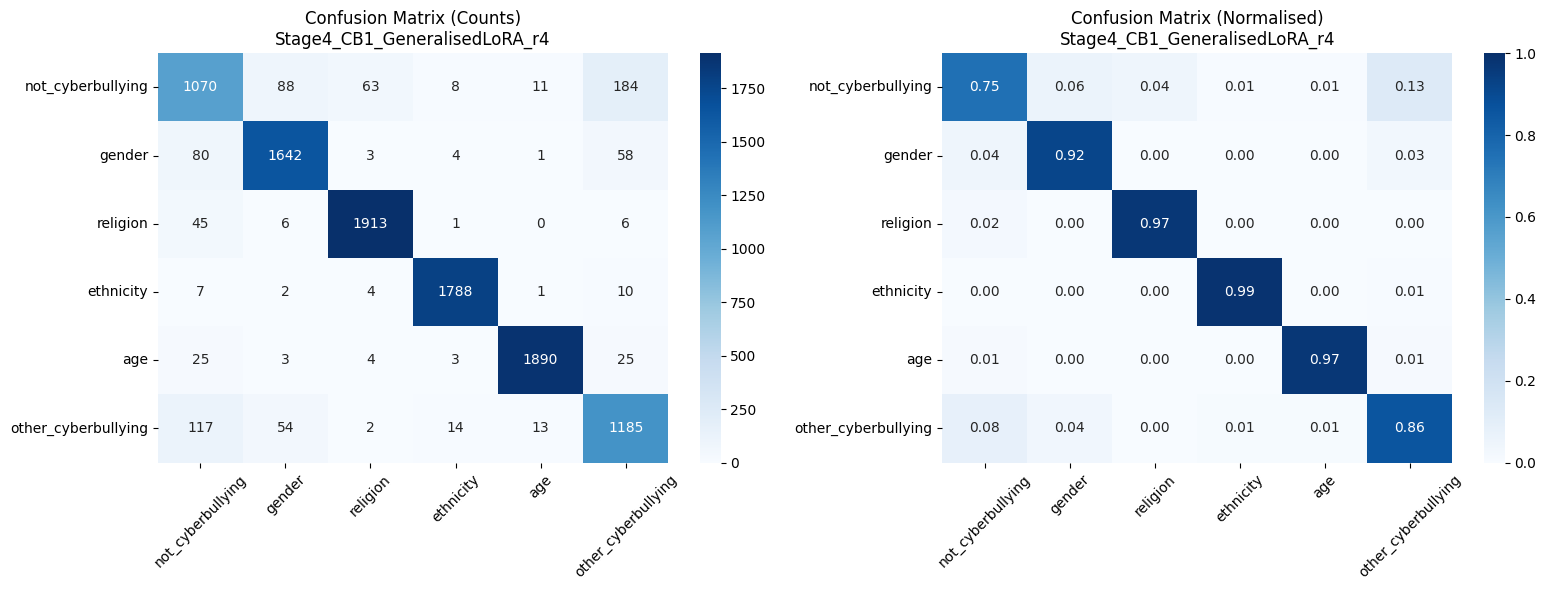


✓ Results saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Gemma2_9B/GeneralisedLoRA_r4

───────────────────────────────────────────────────────
  Rank sweep: r=8
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 4 — GENERALISED LoRA  |  GeneralisedLoRA_r8
  Model: google/gemma-2-9b-it  |  Rank: 8  |  Scaling: 1.0
  Formula: Wf = W(I + UV) + AB   [both paths active]

[1] Loading tokenizer...
   Vocab: 256,000
[2] Preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

...

   PEFT shell registered.
[4] Injecting GeneralisedLoRALayer...
  ✓ Replaced 168 PEFT LoraLayers with GeneralisedLoRALayer
   Trainable: 18,945,024 | Total: 5,098,874,368 | 0.3716%
Class weights:
  [0] not_cyberbullying         1.1500
  [1] gender                    0.9458
  [2] religion                  0.9007
  [3] ethnicity                 0.8859
  [4] age                       0.8985
  [5] other_cyberbullying       1.2190

[5] Training (Wf = W(I+UV) + AB, r=8)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.442600,1.030185,0.818843,0.790658,0.786178
400,0.770100,0.468399,0.860345,0.847987,0.833478
600,0.513500,0.874420,0.837625,0.791754,0.811742
800,0.781900,0.740578,0.807634,0.787126,0.785187
1000,0.497800,0.626256,0.868828,0.851243,0.844749
1200,0.743700,0.489976,0.872160,0.855221,0.851019
1400,0.652400,0.597534,0.865192,0.845580,0.840922
1600,0.722300,0.489042,0.881248,0.864060,0.859006
1800,0.442700,0.570911,0.873069,0.858640,0.849272
2000,0.545300,0.616068,0.877007,0.861157,0.856700


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

   Time: 12874s (3.58 hrs)
   Stability: 0.2248  🔴 Unstable
✓ Saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Gemma2_9B/GeneralisedLoRA_r8/stability_GeneralisedLoRA_r8.png


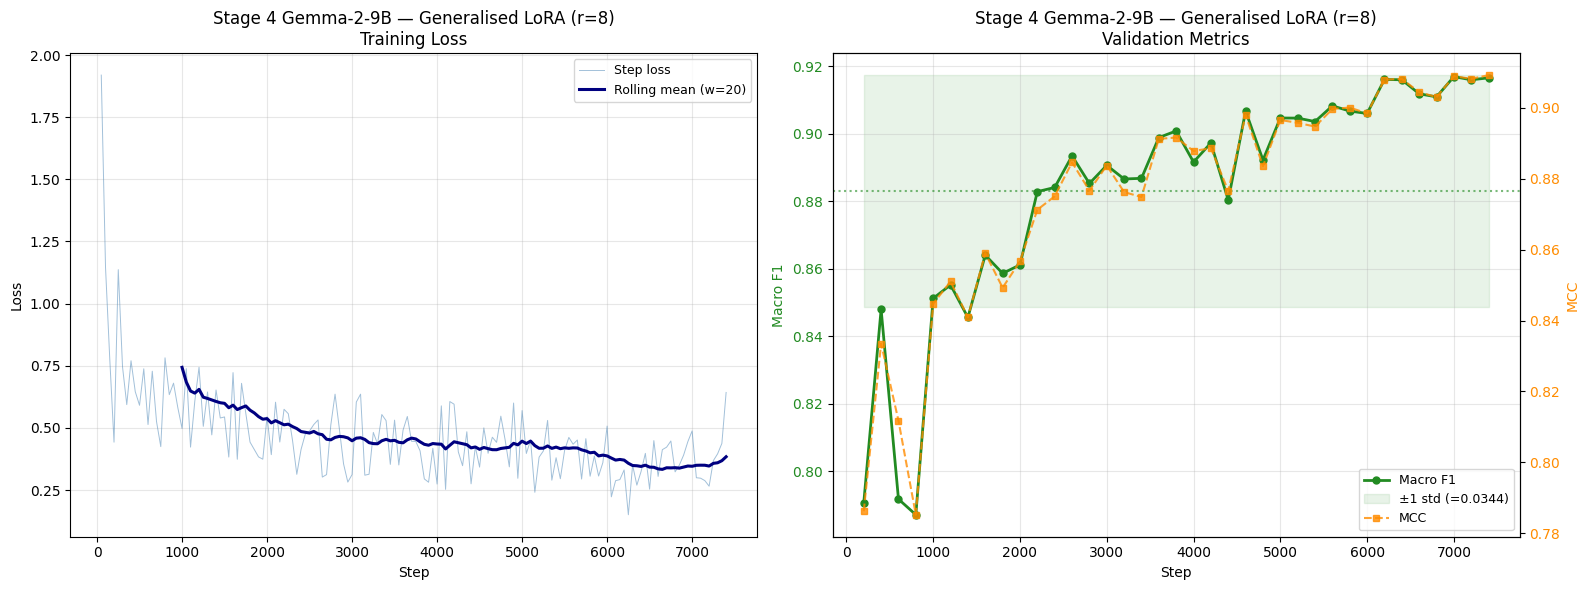


[6] Computing effective rank...
   Eff.Rank Wf: 2815.98  ← S2: 2815.98 | S3: 2815.98
   Eff.Rank UV: 8.00 | AB: 8.00
   Layers: 168

[7] Evaluating on test set...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — Stage4_CB1_GeneralisedLoRA_r8
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9155
  Macro F1          : 0.9048  ← PRIMARY METRIC
  Weighted F1       : 0.9153
  Balanced Accuracy : 0.9054
  MCC               : 0.8983  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7853    0.7374    0.7606      1424
             gender     0.9198    0.9111    0.9154      1788
           religion     0.9607    0.9685    0.9646      1971
          ethnicity     0.9830    0.9906    0.9868      1812
                age     0.9854    0.9672    0.9762      1950
other_cyberbullying     0.7946    0.8578    0.8250      1385

           accur

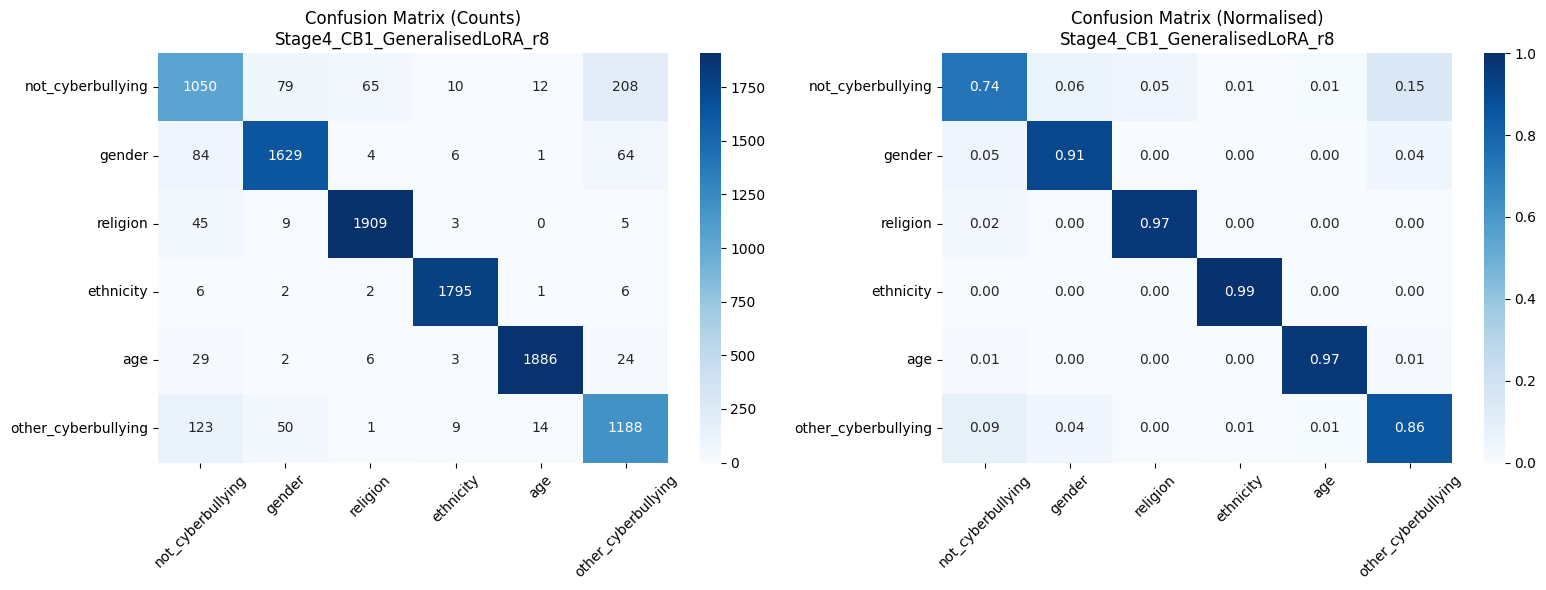


✓ Results saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Gemma2_9B/GeneralisedLoRA_r8

───────────────────────────────────────────────────────
  Rank sweep: r=32
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 4 — GENERALISED LoRA  |  GeneralisedLoRA_r32
  Model: google/gemma-2-9b-it  |  Rank: 32  |  Scaling: 1.0
  Formula: Wf = W(I + UV) + AB   [both paths active]

[1] Loading tokenizer...
   Vocab: 256,000
[2] Preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

...

   PEFT shell registered.
[4] Injecting GeneralisedLoRALayer...
  ✓ Replaced 168 PEFT LoraLayers with GeneralisedLoRALayer
   Trainable: 75,715,584 | Total: 5,155,644,928 | 1.4686%
Class weights:
  [0] not_cyberbullying         1.1500
  [1] gender                    0.9458
  [2] religion                  0.9007
  [3] ethnicity                 0.8859
  [4] age                       0.8985
  [5] other_cyberbullying       1.2190

[5] Training (Wf = W(I+UV) + AB, r=32)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.691900,1.192975,0.800969,0.776081,0.767981
400,0.794200,0.598319,0.857922,0.839812,0.831440
600,0.624900,1.139080,0.807331,0.746350,0.775715
800,0.876800,0.512618,0.823690,0.806437,0.796229
1000,0.531300,0.829846,0.826113,0.799448,0.794120
1200,0.950600,0.493062,0.870948,0.852565,0.846697
1400,0.916500,0.647029,0.827022,0.805148,0.792260
1600,1.004200,0.540881,0.847319,0.835554,0.817341
1800,0.558600,0.565490,0.859437,0.845825,0.833041
2000,0.770200,0.778219,0.833687,0.799006,0.807386


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/

   Time: 12880s (3.58 hrs)
   Stability: 0.1930  🔴 Unstable
✓ Saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Gemma2_9B/GeneralisedLoRA_r32/stability_GeneralisedLoRA_r32.png


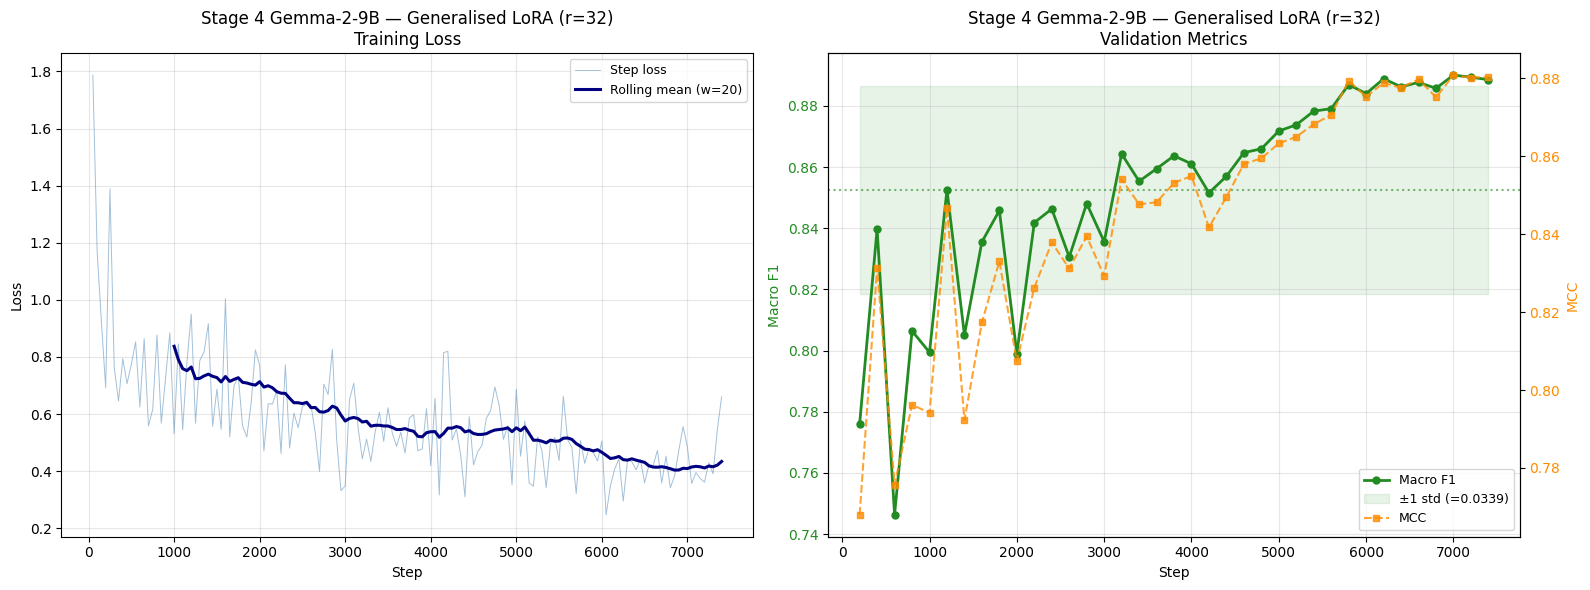


[6] Computing effective rank...
   Eff.Rank Wf: 2815.56  ← S2: 2815.98 | S3: 2815.98
   Eff.Rank UV: 32.00 | AB: 32.00
   Layers: 168

[7] Evaluating on test set...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — Stage4_CB1_GeneralisedLoRA_r32
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.8904
  Macro F1          : 0.8747  ← PRIMARY METRIC
  Weighted F1       : 0.8893
  Balanced Accuracy : 0.8754
  MCC               : 0.8682  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7405    0.6433    0.6885      1424
             gender     0.8809    0.8932    0.8870      1788
           religion     0.9499    0.9706    0.9601      1971
          ethnicity     0.9781    0.9873    0.9827      1812
                age     0.9823    0.9703    0.9763      1950
other_cyberbullying     0.7220    0.7877    0.7535      1385

           ac

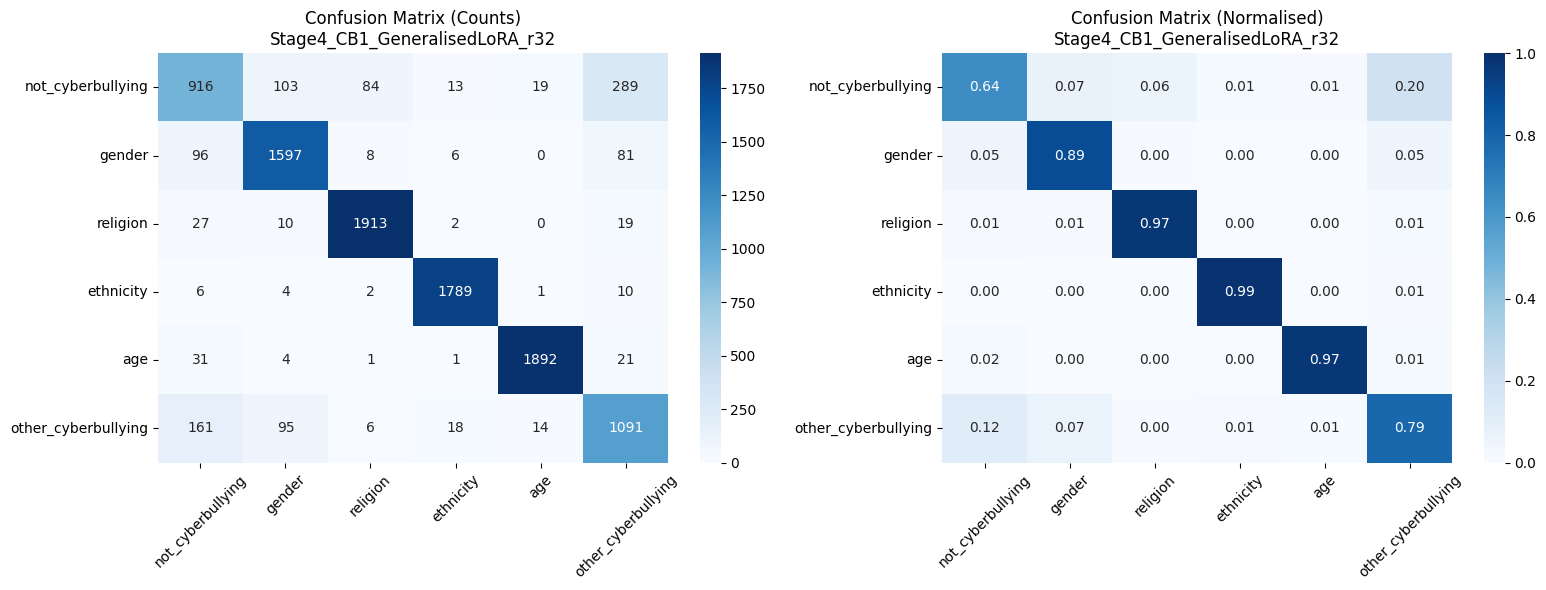


✓ Results saved → /content/drive/MyDrive/Results/CB1_GeneralisedLoRA_Gemma2_9B/GeneralisedLoRA_r32

═════════════════════════════════════════════════════════════════════════════════════════════════════════
STAGE 4a CB1 GEMMA-2-9B — 4-RANK SUMMARY TABLE
═════════════════════════════════════════════════════════════════════════════════════════════════════════
   r |    Trainable |  Macro F1 |     MCC | Eff.Rank Wf | Eff.Rank UV | Eff.Rank AB | Stability |  Time(h) | Trend
─────────────────────────────────────────────────────────────────────────────────────────────────────────
   4 |    9,483,264 |    0.9082 |  0.9019 |     2815.98 |        4.00 |        4.00 |    0.2302 |     3.58 |  ★
   8 |   18,945,024 |    0.9048 |  0.8983 |     2815.98 |        8.00 |        8.00 |    0.2248 |     3.58 | ↓
  16 |   37,868,544 |    0.9014 |  0.8952 |     2815.97 |       16.00 |       16.00 |    0.2169 |     3.49 | ↓
  32 |   75,715,584 |    0.8747 |  0.8682 |     2815.56 |       32.00 |       32.00 |

In [12]:
all_rank_results = {16: results_r16}

for rank in RANK_SWEEP:
    print(f'\n{"─"*55}\n  Rank sweep: r={rank}\n{"─"*55}')
    result = run_generalised_lora(
        train_df=train_df, val_df=val_df, test_df=test_df,
        lora_rank=rank, run_label=f'GeneralisedLoRA_r{rank}')
    all_rank_results[rank] = result

print(f'\n{"═"*105}')
print('STAGE 4a CB1 GEMMA-2-9B — 4-RANK SUMMARY TABLE')
print(f'{"═"*105}')
print(f'{"r":>4} | {"Trainable":>12} | {"Macro F1":>9} | {"MCC":>7} | '
      f'{"Eff.Rank Wf":>11} | {"Eff.Rank UV":>11} | {"Eff.Rank AB":>11} | '
      f'{"Stability":>9} | {"Time(h)":>8} | Trend')
print(f'{"─"*105}')

sorted_ranks = sorted(all_rank_results.keys())
prev_f1 = None
for r in sorted_ranks:
    res = all_rank_results[r]
    trend = ''
    if prev_f1 is not None:
        trend = '↑' if res['macro_f1'] > prev_f1 else ('↓' if res['macro_f1'] < prev_f1 else '→')
    best_mark = ' ★' if res['macro_f1'] == max(v['macro_f1'] for v in all_rank_results.values()) else ''
    print(f'{r:>4} | {res["trainable_params"]:>12,} | {res["macro_f1"]:>9.4f} | {res["mcc"]:>7.4f} | '
          f'{res["avg_eff_rank_Wf"]:>11.2f} | {res["avg_eff_rank_UV"]:>11.2f} | '
          f'{res["avg_eff_rank_AB"]:>11.2f} | {res["stability_score"]:>9.4f} | '
          f'{res["train_runtime_s"]/3600:>8.2f} | {trend}{best_mark}')
    prev_f1 = res['macro_f1']

print()
print('  S2 Gemma-2-9B: r=4: 0.8951 | r=8: 0.8954 | r=16: 0.8986 | r=32: 0.9010★')
print('  S3 Gemma-2-9B: r=4: 0.8757 | r=8: 0.8925 | r=16: 0.8937 | r=32: 0.8944')

# Eff. rank constancy
eff_ranks = [all_rank_results[r]['avg_eff_rank_Wf'] for r in sorted_ranks if all_rank_results[r]['avg_eff_rank_Wf'] > 0]
if eff_ranks:
    eff_range = max(eff_ranks) - min(eff_ranks)
    print(f'\n  Eff. rank Wf range: {eff_range:.2f}  (S2: 0.00 | S3: 0.03)')
    if eff_range < 1.0:
        print('  ✓ PERFECTLY CONSTANT — strongest Proposition 1 validation continues in S4')
    else:
        print('  ⚠ Varies — report in paper')

# Save final CSV
summary_rows = []
for r in sorted_ranks:
    res = all_rank_results[r]
    summary_rows.append({
        'model': 'Gemma-2-9B', 'stage': '4a', 'formula': 'Wf=W(I+UV)+AB',
        'dataset': 'CB1', 'rank': r, 'trainable_params': res['trainable_params'],
        'macro_f1': res['macro_f1'], 'mcc': res['mcc'],
        'accuracy': res['accuracy'], 'balanced_accuracy': res['balanced_accuracy'],
        'avg_eff_rank_Wf': res['avg_eff_rank_Wf'],
        'avg_eff_rank_UV': res['avg_eff_rank_UV'], 'avg_eff_rank_AB': res['avg_eff_rank_AB'],
        'stability_score': res['stability_score'], 'train_runtime_s': res['train_runtime_s'],
    })
summary_path = os.path.join(OUTPUT_DIR, 'stage4a_cb1_gemma2_9b_rank_sweep_FINAL.csv')
pd.DataFrame(summary_rows).to_csv(summary_path, index=False)
print(f'\n✓ Final results saved → {summary_path}')


---
## Step 14: Final Summary

In [13]:
print('\n' + '═'*70)
print('  STAGE 4a COMPLETE — GENERALISED LoRA | Gemma-2-9B-IT')
print('  Formula: Wf = W(I + UV) + AB  |  CB1 6-Class')
print('═'*70)

best_r = max(all_rank_results, key=lambda r: all_rank_results[r]['macro_f1'])
best = all_rank_results[best_r]

print(f'\n── BEST RESULT (r={best_r}) ──')
print(f'  Macro F1          : {best["macro_f1"]:.4f}   ← PRIMARY')
print(f'  MCC               : {best["mcc"]:.4f}')
print(f'  Eff. rank (Wf)    : {best["avg_eff_rank_Wf"]:.2f}   ← S2/S3: 2815.98')
print(f'  Stability         : {best["stability_score"]:.4f}')
print(f'  Time              : {best["train_runtime_s"]/3600:.2f} hrs')

print(f'\n── CROSS-STAGE COMPARISON (Gemma-2-9B, best rank each stage) ──')
print(f'  Stage 2 (r=32): F1=0.9010 ★ | MCC=0.8936 | Eff.Rank=2815.98')
print(f'  Stage 3 (r=32): F1=0.8944   | MCC=0.8878 | Eff.Rank=2815.95')
print(f'  Stage 4 (r={best_r:>2}): F1={best["macro_f1"]:.4f}   | MCC={best["mcc"]:.4f} | Eff.Rank={best["avg_eff_rank_Wf"]:.2f}')
print(f'  Δ vs S2 best      : {best["macro_f1"] - 0.9010:+.4f}')
print(f'  Δ vs S3 best      : {best["macro_f1"] - 0.8944:+.4f}')

print(f'\n── OVERALL CB1 TARGETS ──')
print(f'  Stage 2 best overall: F1=0.9010 (Gemma-2-9B r=32)')
print(f'  Stage 3 best overall: F1=0.8988 (Gemma-3-27B r=16)')
print(f'  Stage 4 Llama-3B   : F1=0.8981 (r=16)')
print(f'  Stage 4 Mistral-7B : F1=0.8975 (r=16)')
print(f'  Stage 4 Gemma-2-9B : F1={best["macro_f1"]:.4f} (r={best_r})')

if best["macro_f1"] > 0.9010:
    print(f'\n  ★★★ STAGE 4 GEMMA-2-9B BEATS THE OVERALL STAGE 2 CHAMPION (0.9010) ★★★')
    print(f'  The central research hypothesis is CONFIRMED.')
    print(f'  Generalised LoRA (Wf = W(I+UV) + AB) outperforms both additive and multiplicative alone.')
elif best["macro_f1"] > 0.8986:
    print(f'\n  ✓ Stage 4 beats Stage 2 Gemma-2-9B r=16 (0.8986)')
    print(f'  May beat 0.9010 on other models (Phi-4, Gemma-3-27B)')
else:
    print(f'\n  → Below Stage 2 Gemma-2-9B — check remaining models.')

print(f'\n  → Next: Stage 4 CB1 Phi-4 or Gemma-3-27B')



══════════════════════════════════════════════════════════════════════
  STAGE 4a COMPLETE — GENERALISED LoRA | Gemma-2-9B-IT
  Formula: Wf = W(I + UV) + AB  |  CB1 6-Class
══════════════════════════════════════════════════════════════════════

── BEST RESULT (r=4) ──
  Macro F1          : 0.9082   ← PRIMARY
  MCC               : 0.9019
  Eff. rank (Wf)    : 2815.98   ← S2/S3: 2815.98
  Stability         : 0.2302
  Time              : 3.58 hrs

── CROSS-STAGE COMPARISON (Gemma-2-9B, best rank each stage) ──
  Stage 2 (r=32): F1=0.9010 ★ | MCC=0.8936 | Eff.Rank=2815.98
  Stage 3 (r=32): F1=0.8944   | MCC=0.8878 | Eff.Rank=2815.95
  Stage 4 (r= 4): F1=0.9082   | MCC=0.9019 | Eff.Rank=2815.98
  Δ vs S2 best      : +0.0072
  Δ vs S3 best      : +0.0138

── OVERALL CB1 TARGETS ──
  Stage 2 best overall: F1=0.9010 (Gemma-2-9B r=32)
  Stage 3 best overall: F1=0.8988 (Gemma-3-27B r=16)
  Stage 4 Llama-3B   : F1=0.8981 (r=16)
  Stage 4 Mistral-7B : F1=0.8975 (r=16)
  Stage 4 Gemma-2-9B : F1=0.